In [35]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import linear_kernel
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('books_data.csv')
df.head()

,bookID,title,authors,average_rating
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bookID          11127 non-null  int64 
 1   title           11127 non-null  object
 2   authors         11127 non-null  object
 3   average_rating  11127 non-null  object
dtypes: int64(1), object(3)
memory usage: 347.8+ KB


In [38]:
df.columns

Index(['bookID', 'title', 'authors', 'average_rating'], dtype='object')

In [39]:
fig = px.histogram(df, x='average_rating', title='Distribution of Average Ratings')
fig.update_layout(xaxis_title='Average Rating', yaxis_title='Count')
fig.show()

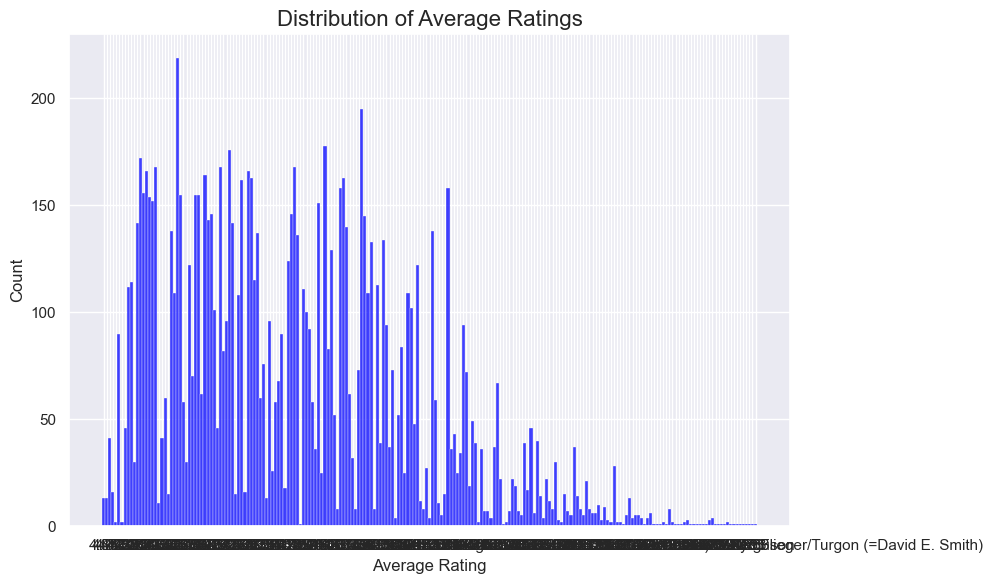

In [40]:
plt.figure(figsize=(10, 6))
sns.set(style='darkgrid')
sns.histplot(data=df, x='average_rating', bins=30, kde=False, color='blue')
plt.xlabel('Average Rating')

plt.title('Distribution of Average Ratings', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [41]:
top_authors = df['authors'].value_counts().head(10)
top_authors

authors
Stephen King           40
P.G. Wodehouse         40
Rumiko Takahashi       39
Orson Scott Card       35
Agatha Christie        33
Piers Anthony          30
Mercedes Lackey        29
Sandra Brown           29
Dick Francis           28
Laurell K. Hamilton    23
Name: count, dtype: int64

In [42]:
fig = px.bar(top_authors, x=top_authors.values, y=top_authors.index, orientation='h',title='Top 10 Authors by Number of Books')
fig.update_layout(xaxis_title='Number of books', yaxis_title='Authors',)

fig.show()

In [43]:
# Convert 'average_rating' to numeric data type
df['average_rating'] = pd.to_numeric(df['average_rating'], errors='coerce')

In [44]:
# Create a new column 'book_content' by combining 'title' and 'authors'
df['book_content'] = df['title'] + ' ' + df['authors']

In [49]:
df.head()

,bookID,title,authors,average_rating,book_content
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,Harry Potter and the Half-Blood Prince (Harry ...
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,Harry Potter and the Order of the Phoenix (Har...
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,Harry Potter and the Chamber of Secrets (Harry...
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,Harry Potter and the Prisoner of Azkaban (Harr...
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,Harry Potter Boxed Set Books 1-5 (Harry Potte...


In [45]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['book_content'])

In [46]:
# Compute the cosine similarity between books
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [48]:
df.head()

,bookID,title,authors,average_rating,book_content
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,Harry Potter and the Half-Blood Prince (Harry ...
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,Harry Potter and the Order of the Phoenix (Har...
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,Harry Potter and the Chamber of Secrets (Harry...
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,Harry Potter and the Prisoner of Azkaban (Harr...
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,Harry Potter Boxed Set Books 1-5 (Harry Potte...


In [50]:
#Compute the cosine similarity
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [54]:
def recommend_books(book_title, cosine_sim = cosine_sim):
    # Get the index of the book that matches the title
    idx = df[df['title'] == book_title].index[0]

    # Get the pairwise similarity scores of all books with that book
    sim_scores = list(enumerate(cosine_sim[idx]))

    #Sort the books on the similarity scores
    sim_scores = sorted(sim_scores, key = lambda x : x[1], reverse = True)

    # Get the scores of the 10 most similar books
    sim_scores = sim_scores[1:11]

    # Get the book indices
    book_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar books
    return df['title'].iloc[book_indices]


In [58]:
book_title = 'Sam Walton: Made In America'
recommended_books = recommend_books(book_title)
print(recommended_books)

2788                              Dumpy's Valentine
3559         See You Around  Sam! (Sam Krupnik  #3)
7502                           The Song of Rhiannon
8998                   The Deming Management Method
3322                                   Buried Child
5850                                     Waterworks
454     Plays 1: Medea/The Phoenician Women/Bacchae
3323                                    Seven Plays
7575           Sam And The Firefly (Beginner Books)
6189          Dubliners: Text  Criticism  and Notes
Name: title, dtype: object
